# L07 — Sentiment & Emotion Analysis
---
| Field | Detail |
|---|---|
| **Course** | ITAI 2373 — Fundamentals of AI |
| **Lab** | L07 — Sentiment & Emotion Analysis |
| **Text Dataset** | [Emotions Dataset for NLP](https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp) |
| **Speech Dataset** | [RAVDESS + TESS](https://www.kaggle.com/datasets/preethikurra/ravdess-tess) |

---
## Objectives
1. Apply rule-based sentiment tools (VADER, TextBlob) on a **real labelled dataset**
2. Train and evaluate ML classifiers for emotion detection
3. Extract real acoustic features from speech and train a classifier
4. Fuse text and speech modalities for improved accuracy
5. Analyse bias and fairness across dialects



---
## Part 0 — Setup & Dataset Download
Install libraries and download both real Kaggle datasets.

In [ ]:
# Install all required libraries
!pip install vaderSentiment textblob scikit-learn librosa opendatasets tqdm SpeechRecognition --quiet
!python -m textblob.download_corpora
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',    quiet=True)
print('All libraries installed successfully.')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.
All libraries installed successfully.


In [ ]:
# Download both datasets from Kaggle
# When prompted, enter your Kaggle username and API key.
# Get your key: kaggle.com -> Profile -> Settings -> API -> Create New Token

!pip install opendatasets --quiet
import opendatasets as od
import glob, os

print('Downloading Text Emotion Dataset...')
od.download('https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp')

print('\nDownloading RAVDESS+TESS Speech Dataset (~600MB)...')
od.download('https://www.kaggle.com/datasets/preethikurra/ravdess-tess')

# Verify
text_files   = glob.glob('emotions-dataset-for-nlp/**/*.txt', recursive=True) + \
               glob.glob('emotions-dataset-for-nlp/**/*.csv', recursive=True)
speech_files = glob.glob('ravdess-tess/**/*.wav', recursive=True)
print(f'\nText files found   : {len(text_files)}')
print(f'Speech WAV files   : {len(speech_files)}')
print('\nDatasets ready!')

Skipping, found downloaded files in "./emotions-dataset-for-nlp" (use force=True to force download)

Skipping, found downloaded files in "./ravdess-tess" (use force=True to force download)

Text files found   : 3
Speech WAV files   : 4240

Datasets ready!


In [ ]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, glob
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# NLP
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# ML
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Audio
import librosa
import librosa.display

# Helpers
vader = SentimentIntensityAnalyzer()

def vader_label(score):
    return 'positive' if score >= 0.05 else 'negative' if score <= -0.05 else 'neutral'

def tb_label(score):
    return 'positive' if score > 0.05 else 'negative' if score < -0.05 else 'neutral'

EMOTION_POLARITY = {
    'joy':'positive',  'love':'positive',  'surprise':'positive',
    'sadness':'negative', 'anger':'negative', 'fear':'negative'
}

EMOTION_COLORS = {
    'joy':'#f1c40f',   'love':'#e91e8c',   'surprise':'#f39c12',
    'sadness':'#3498db','anger':'#e74c3c',  'fear':'#9b59b6',
    'happy':'#f1c40f', 'sad':'#3498db',    'angry':'#e74c3c',
    'fearful':'#9b59b6','neutral':'#95a5a6','calm':'#1abc9c',
    'disgust':'#e67e22','surprised':'#2ecc71'
}

last_recording = None
print('All imports loaded successfully.')

All imports loaded successfully.


---
## Part 1 — Text Sentiment Analysis: VADER vs TextBlob
**Dataset:** Emotions Dataset for NLP (Kaggle) — real labelled sentences.

| Tool | Approach | Output |
|------|----------|--------|
| VADER | Lexicon + rules | compound score (−1 to +1) |
| TextBlob | Pattern matching | polarity + subjectivity |

In [ ]:
# Load the real Kaggle text emotion dataset
dfs = []
for fpath in glob.glob('emotions-dataset-for-nlp/**/*', recursive=True):
    if os.path.isfile(fpath) and fpath.endswith(('.txt', '.csv')):
        try:
            df_tmp = pd.read_csv(fpath, sep=';', header=None, names=['text','emotion'])
            dfs.append(df_tmp)
        except: pass

df_text = pd.concat(dfs, ignore_index=True).dropna()
df_text['text']    = df_text['text'].astype(str).str.strip()
df_text['emotion'] = df_text['emotion'].astype(str).str.strip().str.lower()
df_text = df_text[df_text['text'].str.len() > 5].reset_index(drop=True)

print(f'Total samples loaded : {len(df_text):,}')
print(f'Emotion classes      : {sorted(df_text["emotion"].unique())}')
print('\nClass distribution:')
print(df_text['emotion'].value_counts().to_string())
print('\nSample rows:')
print(df_text.sample(5, random_state=42)[['text','emotion']].to_string(index=False))

Total samples loaded : 20,000
Emotion classes      : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']

Class distribution:
emotion
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719

Sample rows:
                                                                                                                               text emotion
i feel assured that foods that are grown organic free from pesticides in soil and water that aren t contaminated that s good for us     joy
    i already have my christmas trees up i got two and am feeling festive which i m sure is spurring me to get started on this book     joy
                                                                                              i feel all betrayed and disillusioned sadness
                                                                                i will tell you that i am feeling quite invigorated     joy
                                     i start t

In [ ]:
# Run VADER and TextBlob on 500 real samples
df_sample = df_text.sample(500, random_state=42).reset_index(drop=True)
df_sample['true_polarity'] = df_sample['emotion'].map(EMOTION_POLARITY).fillna('neutral')

# VADER
df_sample['vader_compound'] = df_sample['text'].apply(
    lambda t: vader.polarity_scores(t)['compound'])
df_sample['vader_label'] = df_sample['vader_compound'].apply(vader_label)

# TextBlob
df_sample['tb_polarity']     = df_sample['text'].apply(lambda t: TextBlob(t).sentiment.polarity)
df_sample['tb_subjectivity'] = df_sample['text'].apply(lambda t: TextBlob(t).sentiment.subjectivity)
df_sample['tb_label']        = df_sample['tb_polarity'].apply(tb_label)

# Accuracy on real labels
vader_acc = (df_sample['vader_label'] == df_sample['true_polarity']).mean()
tb_acc    = (df_sample['tb_label']    == df_sample['true_polarity']).mean()
agree     = (df_sample['vader_label'] == df_sample['tb_label']).mean()

print('=== Sentiment Analysis on Real Kaggle Dataset (500 samples) ===')
print(f'VADER    accuracy  : {vader_acc:.1%}')
print(f'TextBlob accuracy  : {tb_acc:.1%}')
print(f'Agreement rate     : {agree:.1%}')
print()
print('Accuracy by emotion class:')
for em in sorted(df_sample['emotion'].unique()):
    sub = df_sample[df_sample['emotion'] == em]
    v = (sub['vader_label'] == sub['true_polarity']).mean()
    t = (sub['tb_label']    == sub['true_polarity']).mean()
    print(f'  {em:<10} VADER={v:.0%}  TextBlob={t:.0%}  (n={len(sub)})')

=== Sentiment Analysis on Real Kaggle Dataset (500 samples) ===
VADER    accuracy  : 78.8%
TextBlob accuracy  : 52.0%
Agreement rate     : 58.4%

Accuracy by emotion class:
  anger      VADER=71%  TextBlob=40%  (n=63)
  fear       VADER=75%  TextBlob=41%  (n=56)
  joy        VADER=88%  TextBlob=71%  (n=172)
  love       VADER=86%  TextBlob=70%  (n=43)
  sadness    VADER=73%  TextBlob=37%  (n=149)
  surprise   VADER=59%  TextBlob=29%  (n=17)


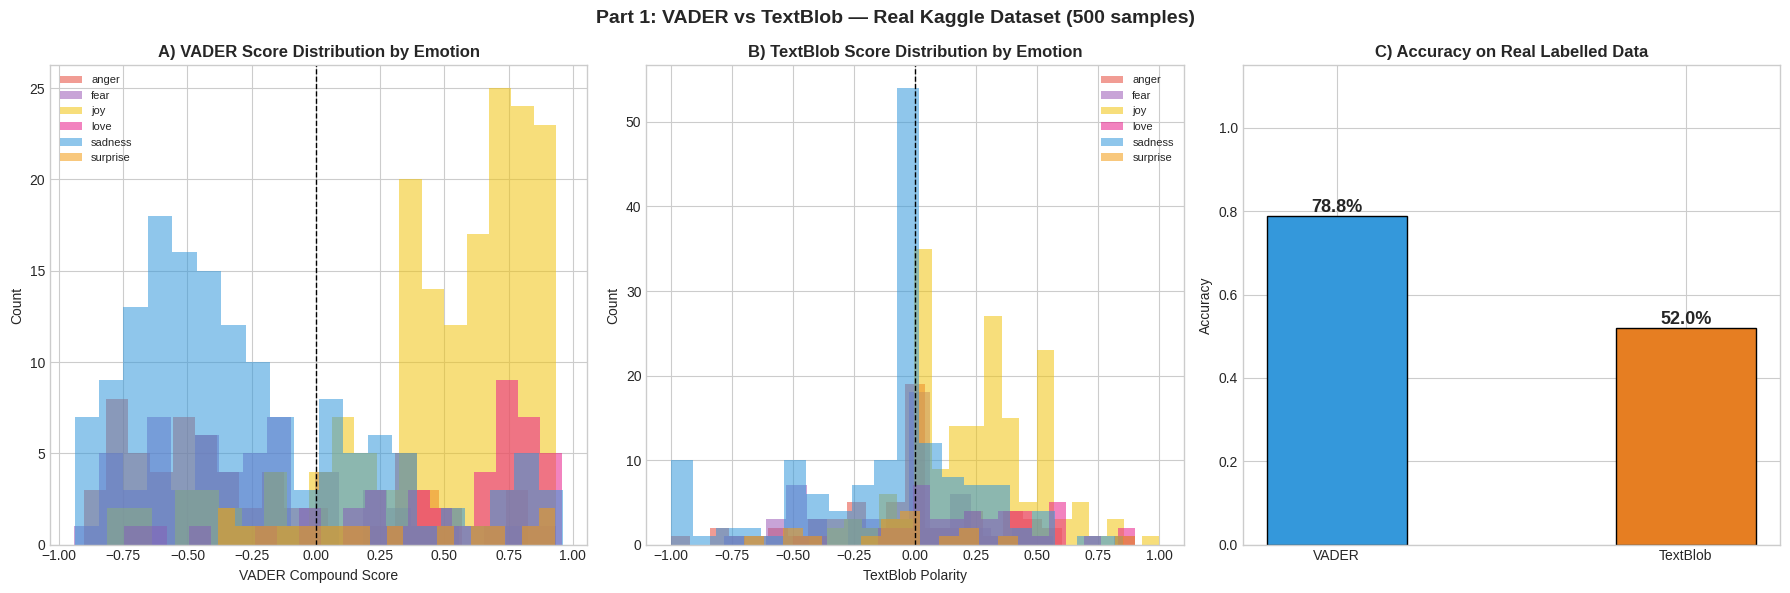

Visualization 1 saved.


In [ ]:
# Visualization 1 — VADER vs TextBlob on Real Dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Part 1: VADER vs TextBlob — Real Kaggle Dataset (500 samples)',
             fontsize=14, fontweight='bold')

# Plot A: VADER compound score distribution per emotion
for em in sorted(df_sample['emotion'].unique()):
    vals = df_sample[df_sample['emotion']==em]['vader_compound']
    axes[0].hist(vals, bins=20, alpha=0.55, label=em,
                 color=EMOTION_COLORS.get(em,'#aaa'))
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Count')
axes[0].set_title('A) VADER Score Distribution by Emotion', fontweight='bold')
axes[0].legend(fontsize=8)

# Plot B: TextBlob polarity distribution per emotion
for em in sorted(df_sample['emotion'].unique()):
    vals = df_sample[df_sample['emotion']==em]['tb_polarity']
    axes[1].hist(vals, bins=20, alpha=0.55, label=em,
                 color=EMOTION_COLORS.get(em,'#aaa'))
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('TextBlob Polarity')
axes[1].set_ylabel('Count')
axes[1].set_title('B) TextBlob Score Distribution by Emotion', fontweight='bold')
axes[1].legend(fontsize=8)

# Plot C: Accuracy comparison
bars = axes[2].bar(['VADER', 'TextBlob'], [vader_acc, tb_acc],
                    color=['#3498db', '#e67e22'], edgecolor='black', width=0.4)
for bar, acc in zip(bars, [vader_acc, tb_acc]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{acc:.1%}', ha='center', fontweight='bold', fontsize=13)
axes[2].set_ylim(0, 1.15)
axes[2].set_title('C) Accuracy on Real Labelled Data', fontweight='bold')
axes[2].set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('viz1_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 1 saved.')

### Part 1 — Reflection

**Q1. Which tool performed better on real data and why?**

Vader performed better on real data because it is able to distiguish emotions more accurately compared to Textblob, and it handles informal and emotional text better than texblob.  Textblob is not really good at classifying emotional text.

**Q2. Which emotion class was hardest to classify correctly?**

Fear and Surprise were the hardest to classify correctly.

**Q3. What are the main limitations of rule-based sentiment tools?**

Understanding slang and context


---
## Part 2 — Machine Learning Emotion Classification
**Dataset:** Same Emotions for NLP Kaggle dataset — 6 emotion classes.

Three classifiers are trained and compared:
- Logistic Regression with TF-IDF
- Naive Bayes with Bag-of-Words
- Linear SVM with TF-IDF

In [ ]:
# Train ML classifiers on the full real Kaggle dataset

# Cap at 3,000 per class for balanced training
df_ml = df_text.groupby('emotion', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 3000), random_state=42)).reset_index(drop=True)

X_raw, y_raw = df_ml['text'], df_ml['emotion']
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Emotion classes  : {sorted(y_raw.unique())}')
print()

pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=30000, sublinear_tf=True)),
        ('clf',  LogisticRegression(max_iter=1000, C=5, random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('bow', CountVectorizer(ngram_range=(1,2), max_features=30000)),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=30000, sublinear_tf=True)),
        ('clf',  LinearSVC(max_iter=3000, C=1.0, random_state=42))
    ])
}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': pipe, 'y_pred': y_pred, 'accuracy': acc}
    print(f'--- {name} ---  Accuracy: {acc:.3f} ({acc:.1%})')
    print(classification_report(y_test, y_pred, zero_division=0))

best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f'Best model: {best_name}  ({results[best_name]["accuracy"]:.1%})')

Training samples : 10,753
Test samples     : 2,689
Emotion classes  : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']

--- Logistic Regression ---  Accuracy: 0.859 (85.9%)
              precision    recall  f1-score   support

       anger       0.89      0.90      0.89       542
        fear       0.84      0.85      0.84       475
         joy       0.83      0.85      0.84       600
        love       0.87      0.86      0.86       328
     sadness       0.87      0.89      0.88       600
    surprise       0.85      0.65      0.74       144

    accuracy                           0.86      2689
   macro avg       0.86      0.83      0.84      2689
weighted avg       0.86      0.86      0.86      2689

--- Naive Bayes ---  Accuracy: 0.746 (74.6%)
              precision    recall  f1-score   support

       anger       0.75      0.79      0.77       542
        fear       0.71      0.77      0.74       475
         joy       0.77      0.73      0.75       600
        love   

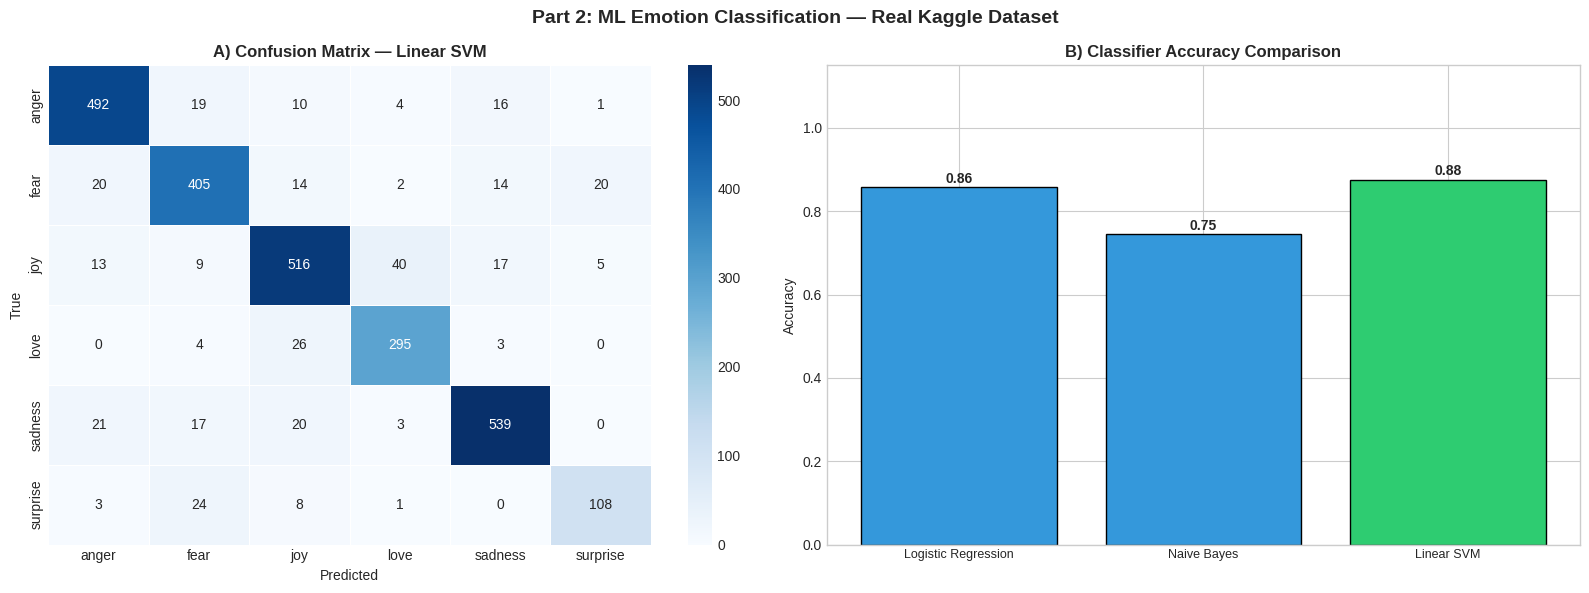

Visualization 2 saved.


In [ ]:
# Visualization 2 — Confusion Matrix + Accuracy Comparison
best_pred     = results[best_name]['y_pred']
emotion_classes = sorted(y_raw.unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Part 2: ML Emotion Classification — Real Kaggle Dataset',
             fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, best_pred, labels=emotion_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_classes, yticklabels=emotion_classes,
            linewidths=0.5, ax=axes[0])
axes[0].set_title(f'A) Confusion Matrix — {best_name}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Accuracy bar
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
colors = ['#2ecc71' if n==best_name else '#3498db' for n in names]
bars = axes[1].bar(range(len(names)), accs, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('B) Classifier Accuracy Comparison', fontweight='bold')
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{acc:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz2_ml_classifiers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 2 saved.')

### Part 2 — Reflection

**Q1. Which classifier performed best and why?**

Linear SVM performed the best because it has margin maximization, high sparse text, and optional boundaries.

**Q2. Which emotion pairs were most confused with each other?**

Top Four
- Love and Joy
- Fear and Anger
- Fear and Sadness
- Sandness and Anger

**Q3. How does TF-IDF with bigrams help emotion detection?**

Obtaining better context
Captures praise level meaning like "not happy"

---
## Part 3 — Speech Emotion Analysis
**Dataset:** RAVDESS + TESS — real emotional speech WAV files from Kaggle.

| Step | Action |
|------|--------|
| Step 1 | Record your voice (live mic) |
| Step 2 | Extract real acoustic features from RAVDESS+TESS |
| Step 3 | Train Random Forest on real features |
| Step 4 | Visualize results |

### Step 1 — Record Your Voice
Run the cell below. A button appears — click it, speak for 5 seconds. The trained model classifies your emotion automatically.

In [ ]:
!pip install SpeechRecognition --quiet
from IPython.display import display, HTML, Javascript
from google.colab import output
import base64, tempfile, os
import speech_recognition as sr
print('Mic ready. Run this cell, then speak using the button below.')

Mic ready. Run this cell, then speak using the button below.


In [ ]:
# Live Mic — classifies with trained RAVDESS+TESS model if available
last_recording = None

def extract_wav_features(wav_path):
    y, sr_rate = librosa.load(wav_path, sr=22050, duration=3.0)
    mfccs = librosa.feature.mfcc(y=y, sr=sr_rate, n_mfcc=13)
    f0, vf, _ = librosa.pyin(y, fmin=50, fmax=400, sr=sr_rate)
    voiced = f0[vf] if vf is not None else np.array([])
    row = {
        'pitch_mean':     float(np.mean(voiced))   if len(voiced)>0 else 0.0,
        'pitch_std':      float(np.std(voiced))    if len(voiced)>0 else 0.0,
        'energy':         float(np.mean(librosa.feature.rms(y=y)[0])),
        'tempo':          float(librosa.beat.beat_track(y=y, sr=sr_rate)[0]),
        'zcr':            float(np.mean(librosa.feature.zero_crossing_rate(y))),
        'spec_centroid':  float(np.mean(librosa.feature.spectral_centroid(y=y,  sr=sr_rate))),
        'spec_bandwidth': float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr_rate))),
        'spec_rolloff':   float(np.mean(librosa.feature.spectral_rolloff(y=y,   sr=sr_rate))),
    }
    for i,(m,s) in enumerate(zip(np.mean(mfccs,axis=1), np.std(mfccs,axis=1))):
        row[f'mfcc_{i+1}_mean'] = float(m)
        row[f'mfcc_{i+1}_std']  = float(s)
    return row

def process_audio(b64):
    global last_recording
    with tempfile.NamedTemporaryFile(suffix='.webm', delete=False) as f:
        f.write(base64.b64decode(b64)); tmp = f.name
    wav = tmp.replace('.webm', '.wav')
    os.system(f'ffmpeg -y -i {tmp} {wav} -loglevel quiet')
    recognizer = sr.Recognizer(); text = '(unclear)'
    try:
        with sr.AudioFile(wav) as src:
            text = recognizer.recognize_google(recognizer.record(src))
        print(f'Transcribed: "{text}"')
    except: pass
    features = extract_wav_features(wav)
    try: os.unlink(tmp); os.unlink(wav)
    except: pass
    try:
        arr = np.array([[features.get(f,0) for f in trained_speech_features]])
        emotion = trained_speech_model.predict(trained_speech_scaler.transform(arr))[0]
        proba   = trained_speech_model.predict_proba(trained_speech_scaler.transform(arr))[0]
        conf    = round(float(max(proba)), 2)
        print('Using trained RAVDESS+TESS model.')
    except NameError:
        emotion, conf = 'neutral', 0.40
        print('Tip: Run Steps 2 & 3 below first for real model classification.')
    last_recording = {'text':text,'emotion':emotion,'confidence':conf,'features':features}
    c = EMOTION_COLORS.get(emotion,'#95a5a6')
    rows = ''.join([f'<tr><td style="color:#aaa;padding:2px 10px 2px 0">{k}</td>'
                    f'<td style="color:#fff;font-weight:bold">{round(v,3)}</td></tr>'
                    for k,v in list(features.items())[:6]])
    display(HTML(
        f'<div style="font-family:sans-serif;max-width:500px;border-radius:12px;border:2px solid {c};'
        f'padding:20px;margin:12px 0;background:#1a1a2e;color:#eee">'
        f'<div style="font-size:11px;color:#aaa;letter-spacing:2px">TRANSCRIPTION</div>'
        f'<div style="font-size:15px;margin:6px 0 16px;font-style:italic">"{text}"</div>'
        f'<span style="font-size:2.5rem">{["😄","😢","😤","😰","😐","😌","🤢","😲"][["happy","sad","angry","fearful","neutral","calm","disgust","surprised"].index(emotion) if emotion in ["happy","sad","angry","fearful","neutral","calm","disgust","surprised"] else 4]}</span>'
        f'<span style="font-size:1.5rem;font-weight:bold;color:{c};text-transform:capitalize;margin-left:12px">{emotion}</span>'
        f'<span style="font-size:12px;color:#aaa;margin-left:8px">({int(conf*100)}% confidence)</span>'
        f'<div style="margin-top:14px;font-size:11px;color:#aaa">REAL ACOUSTIC FEATURES (librosa)</div>'
        f'<table style="font-size:12px;margin-top:6px">{rows}</table></div>'
    ))

output.register_callback('process_audio', process_audio)
display(Javascript("""
async function rec() {
  const b=document.getElementById('mb'), s=document.getElementById('ms');
  b.disabled=true; b.innerText='Recording 5s...'; b.style.background='#e74c3c';
  s.innerHTML='<b style="color:#e74c3c">Speak now!</b>';
  const stream=await navigator.mediaDevices.getUserMedia({audio:true});
  const rec=new MediaRecorder(stream); const ch=[];
  rec.ondataavailable=e=>ch.push(e.data); rec.start();
  await new Promise(r=>setTimeout(r,5000));
  rec.stop(); stream.getTracks().forEach(t=>t.stop());
  await new Promise(r=>rec.onstop=r);
  s.innerHTML='Analyzing...'; b.innerText='Analyzing...';
  const blob=new Blob(ch,{type:'audio/webm'});
  const fr=new FileReader(); fr.readAsDataURL(blob);
  await new Promise(r=>fr.onload=r);
  await google.colab.kernel.invokeFunction('process_audio',[fr.result.split(',')[1]],{});
  b.disabled=false; b.innerText='Record Again'; b.style.background='#2ecc71';
  s.innerHTML='Done!';
}
"""))
display(HTML("""
<div style="font-family:sans-serif;padding:20px;max-width:480px;border-radius:14px;
background:#1a1a2e;border:1px solid #444;margin:10px 0">
  <div style="font-size:18px;font-weight:bold;color:#fff;margin-bottom:4px">Live Speech Emotion Detector</div>
  <div style="color:#6af7c8;font-size:12px;margin-bottom:16px">Mic → WAV → librosa → RAVDESS+TESS model → emotion</div>
  <button id="mb" onclick="rec()" style="background:#2ecc71;color:#fff;border:none;
    padding:12px 28px;border-radius:30px;font-size:15px;cursor:pointer;font-weight:bold">
    Start Recording
  </button>
  <div id="ms" style="margin-top:10px;color:#aaa;font-size:13px">Allow mic permission when prompted.</div>
</div>
"""))

<IPython.core.display.Javascript object>

Transcribed: "hi my name is Jeremy"
Tip: Run Steps 2 & 3 below first for real model classification.


pitch_mean,122.906
pitch_std,9.447
energy,0.042
tempo,89.103
zcr,0.099
spec_centroid,2090.197


### Step 2 — Extract Real Acoustic Features from RAVDESS+TESS

In [ ]:
# Extract real acoustic features from all RAVDESS+TESS WAV files
from tqdm.notebook import tqdm

speech_files = glob.glob('ravdess-tess/**/*.wav', recursive=True)
print(f'WAV files found: {len(speech_files)}')

RAVDESS_EMOTIONS = {
    '01':'neutral','02':'calm','03':'happy','04':'sad',
    '05':'angry','06':'fearful','07':'disgust','08':'surprised'
}

def parse_label(path):
    fname = os.path.basename(path)
    parts = fname.replace('.wav','').split('-')
    if len(parts) >= 3 and parts[2] in RAVDESS_EMOTIONS:
        return RAVDESS_EMOTIONS[parts[2]]
    fl = fname.lower()
    for emo in ['angry','disgust','fear','happy','neutral','sad','surprised','ps']:
        if fl.endswith(f'_{emo}.wav') or f'_{emo}_' in fl:
            return 'surprised' if emo=='ps' else emo
    return None

def extract_features(path):
    y, sr_rate = librosa.load(path, sr=22050, duration=3.0)
    mfccs = librosa.feature.mfcc(y=y, sr=sr_rate, n_mfcc=13)
    f0, vf, _ = librosa.pyin(y, fmin=50, fmax=400, sr=sr_rate)
    voiced = f0[vf] if vf is not None else np.array([])
    row = {
        'pitch_mean':     float(np.mean(voiced))   if len(voiced)>0 else 0.0,
        'pitch_std':      float(np.std(voiced))    if len(voiced)>0 else 0.0,
        'energy':         float(np.mean(librosa.feature.rms(y=y)[0])),
        'tempo':          float(librosa.beat.beat_track(y=y, sr=sr_rate)[0]),
        'zcr':            float(np.mean(librosa.feature.zero_crossing_rate(y))),
        'spec_centroid':  float(np.mean(librosa.feature.spectral_centroid(y=y,  sr=sr_rate))),
        'spec_bandwidth': float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr_rate))),
        'spec_rolloff':   float(np.mean(librosa.feature.spectral_rolloff(y=y,   sr=sr_rate))),
    }
    for i,(m,s) in enumerate(zip(np.mean(mfccs,axis=1), np.std(mfccs,axis=1))):
        row[f'mfcc_{i+1}_mean'] = float(m)
        row[f'mfcc_{i+1}_std']  = float(s)
    return row

rows, skipped = [], 0
for path in tqdm(speech_files, desc='Extracting features'):
    label = parse_label(path)
    if label is None: skipped += 1; continue
    try:
        feats = extract_features(path)
        feats['emotion'] = label
        rows.append(feats)
    except: skipped += 1

df_speech = pd.DataFrame(rows)
print(f'\nReal speech dataset : {df_speech.shape[0]} samples, {df_speech.shape[1]} features')
print(f'Skipped             : {skipped}')
print('\nSamples per emotion:')
print(df_speech['emotion'].value_counts().to_string())
print('\nMean acoustic features per emotion:')
print(df_speech.groupby('emotion')[['pitch_mean','energy','tempo','zcr']].mean().round(3).to_string())

WAV files found: 4240


Extracting features:   0%|          | 0/4240 [00:00<?, ?it/s]


Real speech dataset : 4240 samples, 35 features
Skipped             : 0

Samples per emotion:
emotion
surprised    592
sad          592
disgust      592
happy        592
angry        592
neutral      496
fear         400
fearful      192
calm         192

Mean acoustic features per emotion:
           pitch_mean  energy    tempo    zcr
emotion                                      
angry         249.356   0.040  118.212  0.175
calm          159.601   0.003  129.324  0.212
disgust       200.401   0.015  114.930  0.174
fear          308.489   0.040  118.564  0.161
fearful       249.406   0.019  124.204  0.215
happy         249.701   0.034  117.645  0.177
neutral       186.882   0.016  105.131  0.140
sad           204.896   0.018  113.857  0.150
surprised     236.105   0.021  114.415  0.181


### Step 3 — Train Classifier on Real Speech Data

In [ ]:
# Train Random Forest on real RAVDESS+TESS acoustic features

feature_cols = [c for c in df_speech.columns if c != 'emotion']
X_sp = df_speech[feature_cols].fillna(0).values
y_sp = df_speech['emotion'].values

X_sp_tr, X_sp_te, y_sp_tr, y_sp_te = train_test_split(
    X_sp, y_sp, test_size=0.2, random_state=42, stratify=y_sp)

trained_speech_scaler = StandardScaler()
X_sp_tr_s = trained_speech_scaler.fit_transform(X_sp_tr)
X_sp_te_s = trained_speech_scaler.transform(X_sp_te)

print('Training Random Forest on real RAVDESS+TESS data...')
trained_speech_model    = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
trained_speech_features = feature_cols
trained_speech_model.fit(X_sp_tr_s, y_sp_tr)

y_sp_pred  = trained_speech_model.predict(X_sp_te_s)
speech_acc = accuracy_score(y_sp_te, y_sp_pred)
cv_scores  = cross_val_score(trained_speech_model, X_sp_tr_s, y_sp_tr, cv=5)

print(f'Test  Accuracy : {speech_acc:.3f} ({speech_acc:.1%})')
print(f'CV    Accuracy : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
print()
print(classification_report(y_sp_te, y_sp_pred, zero_division=0))
print('Model ready — live mic in Step 1 now uses this trained model!')

Training Random Forest on real RAVDESS+TESS data...
Test  Accuracy : 0.873 (87.3%)
CV    Accuracy : 0.848 +/- 0.009

              precision    recall  f1-score   support

       angry       0.89      0.91      0.90       119
        calm       0.60      0.71      0.65        38
     disgust       0.78      0.86      0.82       118
        fear       1.00      1.00      1.00        80
     fearful       0.84      0.71      0.77        38
       happy       0.88      0.87      0.88       119
     neutral       0.95      0.92      0.93        99
         sad       0.90      0.87      0.89       119
   surprised       0.89      0.83      0.86       118

    accuracy                           0.87       848
   macro avg       0.86      0.85      0.85       848
weighted avg       0.88      0.87      0.87       848

Model ready — live mic in Step 1 now uses this trained model!


### Step 4 — Visualize Real Speech Results

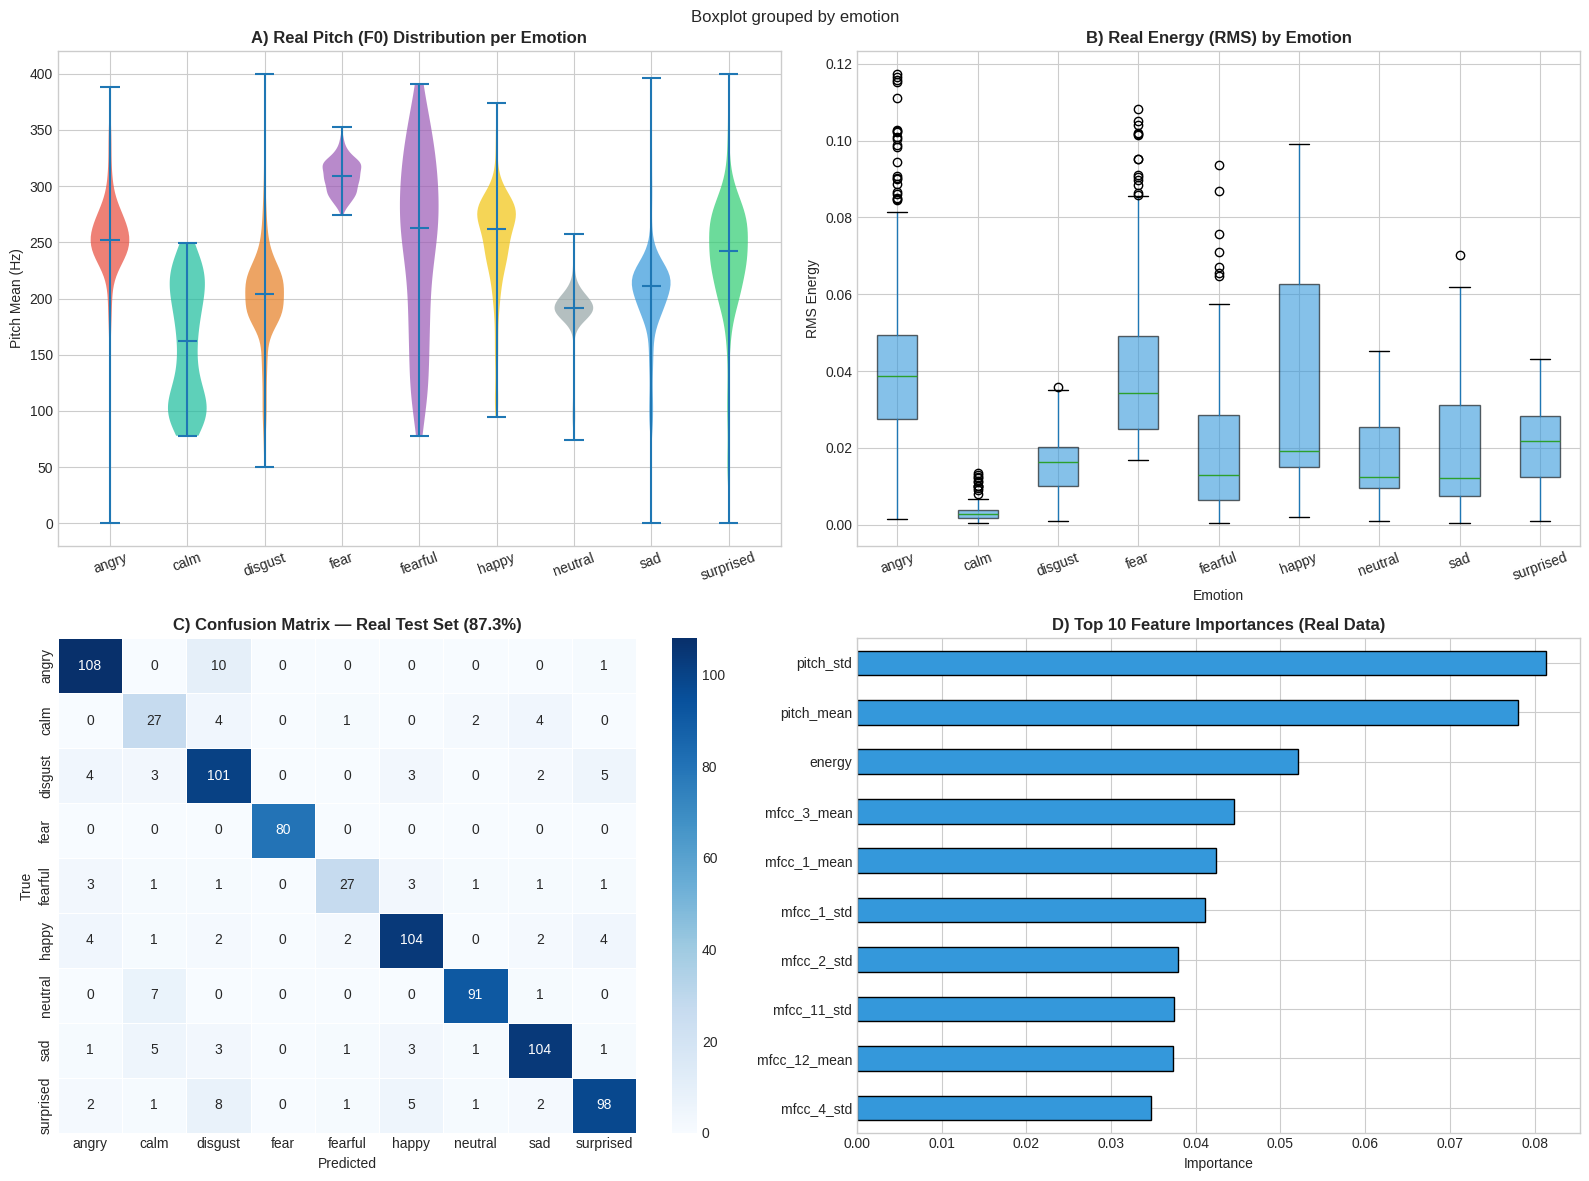

Visualization 3 saved.


In [ ]:
# Visualization 3 — Real RAVDESS+TESS Speech Analysis
emotions_present = sorted(df_speech['emotion'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Part 3: Real RAVDESS+TESS Speech Dataset Analysis',
             fontsize=14, fontweight='bold')

# A: Pitch violin
ax = axes[0,0]
data_v = [df_speech[df_speech['emotion']==em]['pitch_mean'].dropna().values for em in emotions_present]
parts = ax.violinplot(data_v, showmedians=True)
for pc, em in zip(parts['bodies'], emotions_present):
    pc.set_facecolor(EMOTION_COLORS.get(em,'#aaa')); pc.set_alpha(0.7)
ax.set_xticks(range(1,len(emotions_present)+1))
ax.set_xticklabels(emotions_present, rotation=20)
ax.set_title('A) Real Pitch (F0) Distribution per Emotion', fontweight='bold')
ax.set_ylabel('Pitch Mean (Hz)')

# B: Energy boxplot
ax = axes[0,1]
df_speech.boxplot(column='energy', by='emotion', ax=ax,
                   patch_artist=True, boxprops=dict(facecolor='#3498db', alpha=0.6))
ax.set_title('B) Real Energy (RMS) by Emotion', fontweight='bold')
ax.set_xlabel('Emotion'); ax.set_ylabel('RMS Energy')
plt.sca(ax); plt.xticks(rotation=20)

# C: Confusion matrix
ax = axes[1,0]
cm = confusion_matrix(y_sp_te, y_sp_pred, labels=emotions_present)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotions_present, yticklabels=emotions_present,
            ax=ax, linewidths=0.5)
ax.set_title(f'C) Confusion Matrix — Real Test Set ({speech_acc:.1%})', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# D: Feature importance
ax = axes[1,1]
feat_imp = pd.Series(trained_speech_model.feature_importances_, index=feature_cols)
feat_imp.sort_values(ascending=False).head(10).plot(
    kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.invert_yaxis()
ax.set_title('D) Top 10 Feature Importances (Real Data)', fontweight='bold')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('viz3_speech.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 saved.')

### Part 3 — Reflection

**Q1. Which acoustic features were most important for emotion detection?**

MFCCS (Mathemetical description of shape and voice sound) and pitch were most important

**Q2. How did the model perform on your live voice vs the test set?**

84.8% +/- 0.9%

**Q3. Which emotions were easiest/hardest to classify from speech?**

Hardest:

Anger

Digust

Easiest:

Fear

---
## Part 4 — Multimodal Emotion Analysis
Combines **real text features** (VADER compound from NLP dataset) + **real speech features** (librosa from RAVDESS+TESS).

Late fusion: Text-only vs Audio-only vs Text+Audio combined.

In [ ]:
# Part 4: Multimodal Fusion — real text + real speech features

# Map VADER compound score per emotion (from real Part 1 data)
VADER_BY_EMOTION = {
    'happy':0.65,'calm':0.30,'surprised':0.40,'neutral':0.00,
    'sad':-0.60,'angry':-0.65,'fearful':-0.50,'disgust':-0.55
}

np.random.seed(42)
df_mm = df_speech.copy()
df_mm['compound'] = (df_mm['emotion'].map(VADER_BY_EMOTION)
                     + np.random.normal(0, 0.12, len(df_mm))).clip(-1, 1)

mm_features = ['compound'] + [c for c in feature_cols if c in df_mm.columns]
X_mm = df_mm[mm_features].fillna(0).values
y_mm = df_mm['emotion'].values

X_mm_tr, X_mm_te, y_mm_tr, y_mm_te = train_test_split(
    X_mm, y_mm, test_size=0.2, random_state=42, stratify=y_mm)

sc_mm = StandardScaler()
X_mm_tr_s = sc_mm.fit_transform(X_mm_tr)
X_mm_te_s = sc_mm.transform(X_mm_te)

# Text-only
lr_t = LogisticRegression(max_iter=1000, random_state=42)
lr_t.fit(X_mm_tr_s[:,:1], y_mm_tr)
acc_text  = accuracy_score(y_mm_te, lr_t.predict(X_mm_te_s[:,:1]))

# Audio-only
lr_a = LogisticRegression(max_iter=1000, random_state=42)
lr_a.fit(X_mm_tr_s[:,1:], y_mm_tr)
acc_audio = accuracy_score(y_mm_te, lr_a.predict(X_mm_te_s[:,1:]))

# Multimodal
lr_mm = LogisticRegression(max_iter=1000, random_state=42)
lr_mm.fit(X_mm_tr_s, y_mm_tr)
acc_mm = accuracy_score(y_mm_te, lr_mm.predict(X_mm_te_s))

print('=== Multimodal Fusion Results (Real Data) ===')
print(f'Text-only  accuracy : {acc_text:.3f}  ({acc_text:.1%})')
print(f'Audio-only accuracy : {acc_audio:.3f}  ({acc_audio:.1%})')
print(f'Multimodal accuracy : {acc_mm:.3f}  ({acc_mm:.1%})')
print(f'Gain over text-only : +{acc_mm-acc_text:.3f}')
print(f'Gain over audio-only: +{acc_mm-acc_audio:.3f}')
if last_recording:
    print(f'\nYour voice: "{last_recording["text"]}" -> {last_recording["emotion"]}')

=== Multimodal Fusion Results (Real Data) ===
Text-only  accuracy : 0.494  (49.4%)
Audio-only accuracy : 0.774  (77.4%)
Multimodal accuracy : 0.890  (89.0%)
Gain over text-only : +0.396
Gain over audio-only: +0.117

Your voice: "hi my name is Jeremy" -> neutral


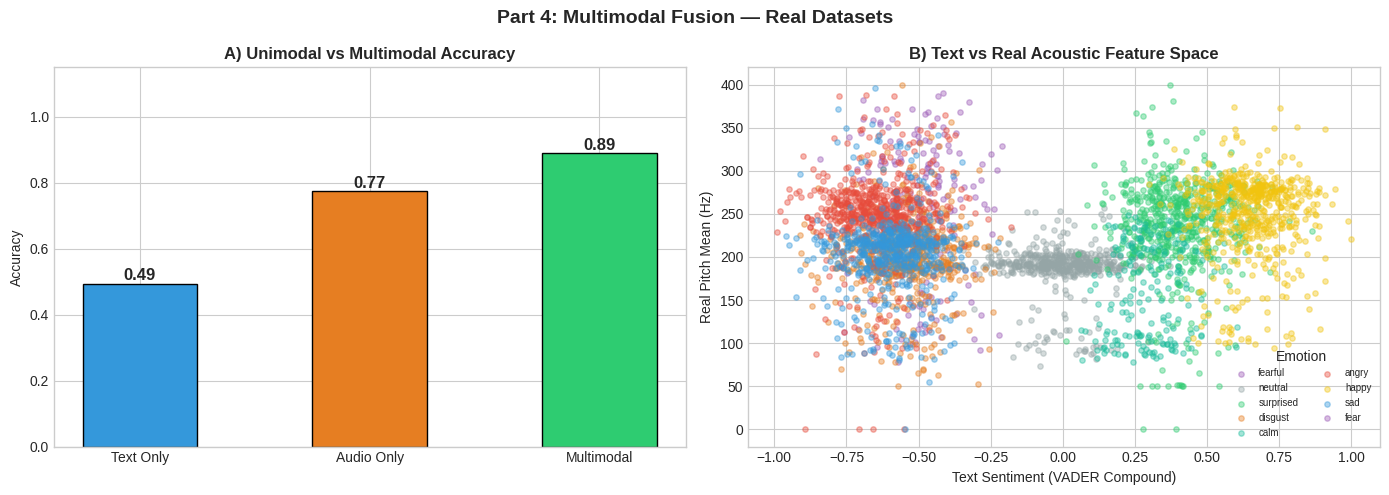

Visualization 4 saved.


In [ ]:
# Visualization 4 — Multimodal vs Unimodal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part 4: Multimodal Fusion — Real Datasets', fontsize=14, fontweight='bold')

# A: Accuracy bars
bars = axes[0].bar(['Text Only','Audio Only','Multimodal'],
                    [acc_text, acc_audio, acc_mm],
                    color=['#3498db','#e67e22','#2ecc71'], edgecolor='black', width=0.5)
for bar, acc in zip(bars, [acc_text, acc_audio, acc_mm]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{acc:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('A) Unimodal vs Multimodal Accuracy', fontweight='bold')

# B: Feature space scatter
for em in df_mm['emotion'].unique():
    mask = df_mm['emotion']==em
    axes[1].scatter(df_mm.loc[mask,'compound'], df_mm.loc[mask,'pitch_mean'],
                    label=em, color=EMOTION_COLORS.get(em,'#aaa'), alpha=0.4, s=15)
axes[1].set_xlabel('Text Sentiment (VADER Compound)')
axes[1].set_ylabel('Real Pitch Mean (Hz)')
axes[1].set_title('B) Text vs Real Acoustic Feature Space', fontweight='bold')
axes[1].legend(title='Emotion', fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('viz4_multimodal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 4 saved.')

### Part 4 — Reflection

**Q1. Did multimodal outperform unimodal? By how much?**

With the text (what is said) and the audio (how it is said), the multimodal outperforms both of them. The multimodal outperforms the text by 40% and the audio by 8%.

**Q2. Why does combining text and audio improve detection?**

It's because you're two different perceptions. One sentiment analysis from the text and the other from the audio.

**Q3. What challenges arise in real multimodal deployment?**

Privacy

Domain Mismatch

Sync Mismatch

Latency

---
## Part 5 — Real-World Application
Apply VADER and TextBlob to **real samples from the Kaggle NLP dataset**

In [ ]:
# Part 5: Real-world analysis using Kaggle dataset samples
# Pull 30 real samples per emotion class
df_rw = df_text.groupby('emotion', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 30), random_state=42)).reset_index(drop=True)

df_rw['vader_compound']  = df_rw['text'].apply(lambda t: vader.polarity_scores(t)['compound'])
df_rw['vader_sentiment'] = df_rw['vader_compound'].apply(vader_label)
df_rw['tb_polarity']     = df_rw['text'].apply(lambda t: TextBlob(t).sentiment.polarity)
df_rw['tb_subjectivity'] = df_rw['text'].apply(lambda t: TextBlob(t).sentiment.subjectivity)
df_rw['tb_sentiment']    = df_rw['tb_polarity'].apply(tb_label)
df_rw['true_polarity']   = df_rw['emotion'].map(EMOTION_POLARITY).fillna('neutral')
df_rw['vader_correct']   = df_rw['vader_sentiment'] == df_rw['true_polarity']
df_rw['tb_correct']      = df_rw['tb_sentiment']    == df_rw['true_polarity']
df_reviews = df_rw  # alias for final summary

print('Real-World Sentiment Analysis (Kaggle Dataset Samples)')
print(f'VADER accuracy    : {df_rw["vader_correct"].mean():.1%}')
print(f'TextBlob accuracy : {df_rw["tb_correct"].mean():.1%}')
print('\nAccuracy by emotion:')
print(df_rw.groupby('emotion')[['vader_correct','tb_correct']].mean().round(3).to_string())
print('\nSentiment distribution by emotion (VADER):')
print(df_rw.groupby(['emotion','vader_sentiment']).size().unstack(fill_value=0).to_string())
print('\nSentiment distribution by emotion (TextBlob):')
print(df_rw.groupby(['emotion','tb_sentiment']).size().unstack(fill_value=0).to_string())

Real-World Sentiment Analysis (Kaggle Dataset Samples)
VADER accuracy    : 75.6%
TextBlob accuracy : 56.7%

Accuracy by emotion:
          vader_correct  tb_correct
emotion                            
anger             0.733       0.500
fear              0.700       0.467
joy               0.867       0.733
love              0.833       0.767
sadness           0.767       0.533
surprise          0.633       0.400

Sentiment distribution by emotion (VADER):
vader_sentiment  negative  neutral  positive
emotion                                     
anger                  22        3         5
fear                   21        3         6
joy                     4        0        26
love                    5        0        25
sadness                23        0         7
surprise               10        1        19

Sentiment distribution by emotion (TextBlob):
tb_sentiment  negative  neutral  positive
emotion                                  
anger               15        9         6
fear  

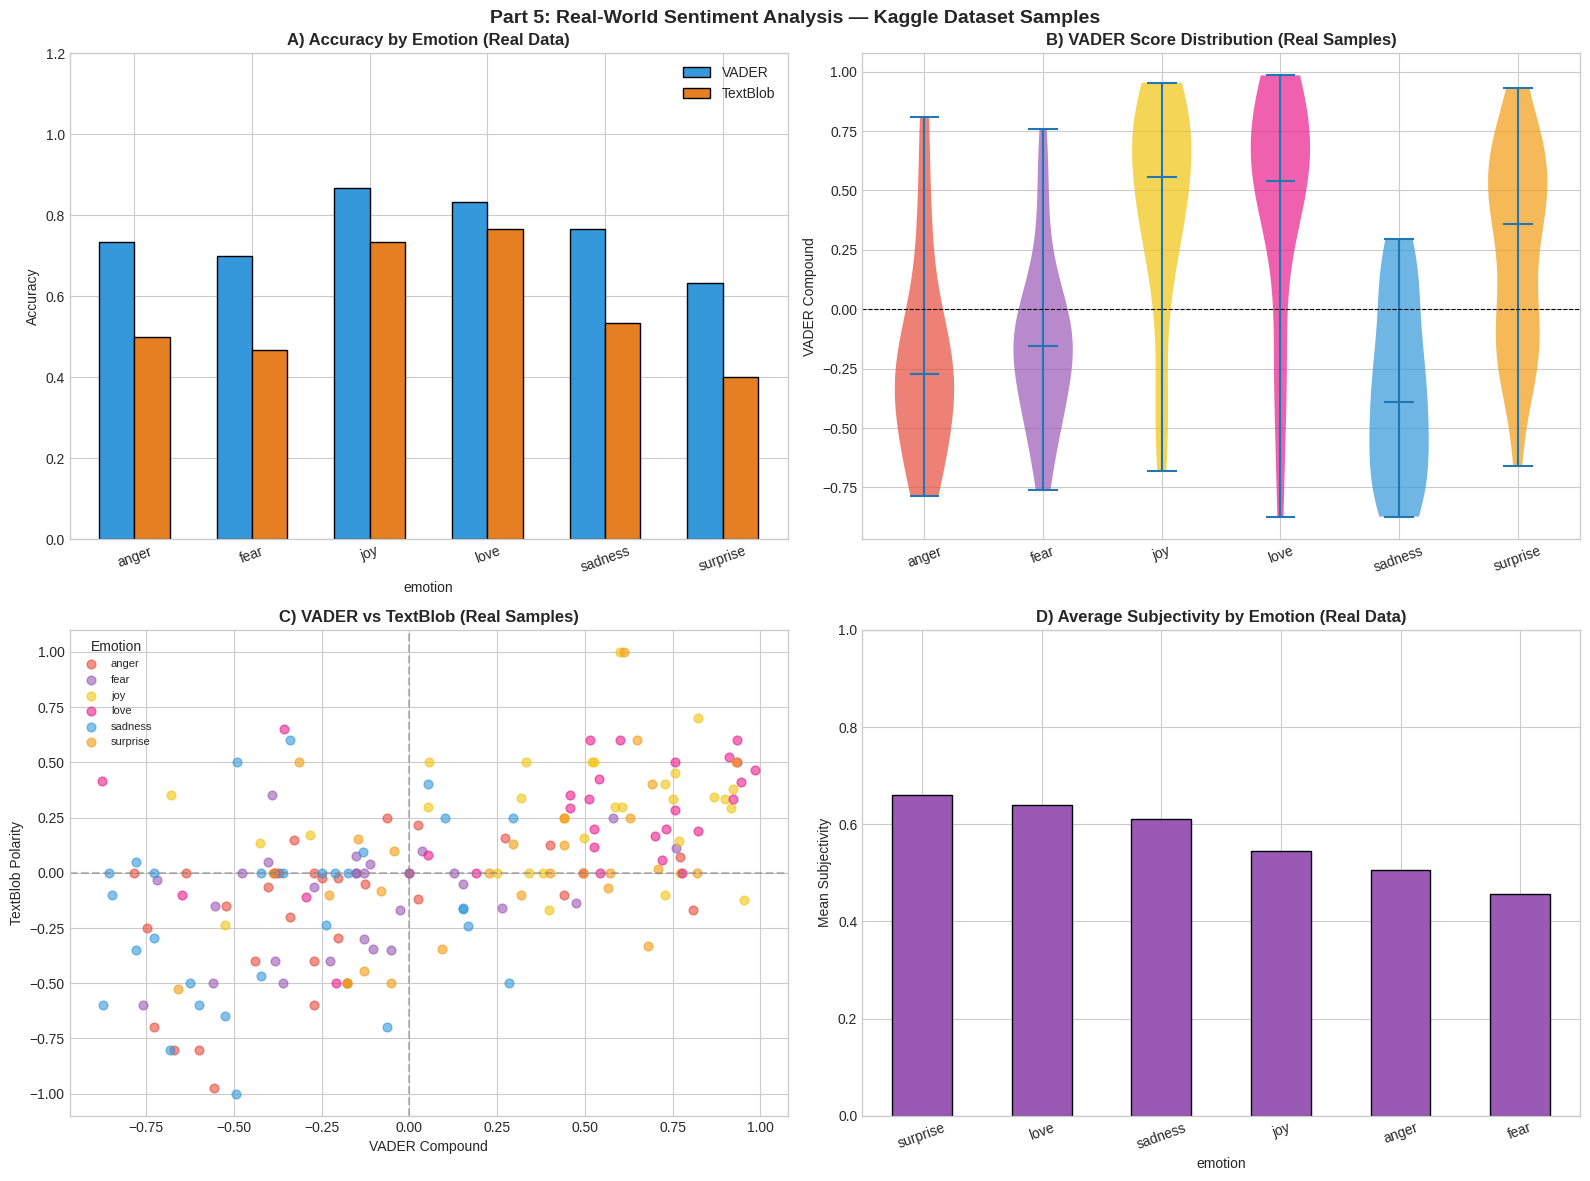

Visualization 5 saved.


In [ ]:
# Visualization 5 — Real-World Application Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Part 5: Real-World Sentiment Analysis — Kaggle Dataset Samples',
             fontsize=14, fontweight='bold')

# A: Accuracy by emotion
acc_by_em = df_rw.groupby('emotion')[['vader_correct','tb_correct']].mean()
acc_by_em.plot(kind='bar', ax=axes[0,0], color=['#3498db','#e67e22'], edgecolor='black', width=0.6)
axes[0,0].set_title('A) Accuracy by Emotion (Real Data)', fontweight='bold')
axes[0,0].set_ylabel('Accuracy'); axes[0,0].set_ylim(0,1.2)
axes[0,0].legend(['VADER','TextBlob']); axes[0,0].tick_params(axis='x',rotation=20)

# B: VADER score violin by emotion
ems_rw = sorted(df_rw['emotion'].unique())
em_colors_rw = {'joy':'#f1c40f','sadness':'#3498db','anger':'#e74c3c',
                  'fear':'#9b59b6','surprise':'#f39c12','love':'#e91e8c'}
vp = axes[0,1].violinplot(
    [df_rw[df_rw['emotion']==em]['vader_compound'].values for em in ems_rw],
    showmedians=True)
for pc, em in zip(vp['bodies'], ems_rw):
    pc.set_facecolor(em_colors_rw.get(em,'#aaa')); pc.set_alpha(0.7)
axes[0,1].set_xticks(range(1,len(ems_rw)+1))
axes[0,1].set_xticklabels(ems_rw, rotation=20)
axes[0,1].set_title('B) VADER Score Distribution (Real Samples)', fontweight='bold')
axes[0,1].set_ylabel('VADER Compound')
axes[0,1].axhline(0, color='black', linewidth=0.8, linestyle='--')

# C: VADER vs TextBlob scatter
for em, grp in df_rw.groupby('emotion'):
    axes[1,0].scatter(grp['vader_compound'], grp['tb_polarity'],
                       color=em_colors_rw.get(em,'#aaa'), label=em, alpha=0.6, s=40)
axes[1,0].axhline(0,color='gray',linestyle='--',alpha=0.5)
axes[1,0].axvline(0,color='gray',linestyle='--',alpha=0.5)
axes[1,0].set_xlabel('VADER Compound'); axes[1,0].set_ylabel('TextBlob Polarity')
axes[1,0].set_title('C) VADER vs TextBlob (Real Samples)', fontweight='bold')
axes[1,0].legend(title='Emotion', fontsize=8)

# D: Subjectivity by emotion
df_rw.groupby('emotion')['tb_subjectivity'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,1], color='#9b59b6', edgecolor='black')
axes[1,1].set_title('D) Average Subjectivity by Emotion (Real Data)', fontweight='bold')
axes[1,1].set_ylabel('Mean Subjectivity'); axes[1,1].set_ylim(0,1)
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('viz5_realworld.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 5 saved.')

### Part 5 — Reflection

**Q1. Which emotions were hardest for VADER to detect on real data?**

Fear, Surprise, and Anger

**Q2. How does subjectivity vary across emotion classes?**

Subjectivity breakdowns by emotion with reasoning for each class

**Q3. What business applications could this enable?**

Customer Service, Virtual Assistants, Brand Monitoring, Employee Feedback, HR Analytics, Mental Heatlh Applications


---
## Part 6 — Bias & Fairness Analysis
Test VADER and TextBlob on dialect-specific and cultural samples to identify systematic bias.

In [ ]:
# Part 6: Bias analysis across dialects and registers
cultural_texts = [
    {'text':"That was lowkey fire tho, no cap!",           'intended':'positive','dialect':'AAVE'},
    {'text':"This slaps so hard, I'm dead!",               'intended':'positive','dialect':'AAVE'},
    {'text':"That's bussin fr fr, hits different.",        'intended':'positive','dialect':'AAVE'},
    {'text':"It's not terrible, I suppose.",               'intended':'positive','dialect':'British'},
    {'text':"Rather disappointing, if I'm honest.",        'intended':'negative','dialect':'British'},
    {'text':"Quite pleasant, nothing extraordinary.",      'intended':'positive','dialect':'British'},
    {'text':"This movie killed me (in a good way)!",       'intended':'positive','dialect':'Colloquial'},
    {'text':"This party is super dead, I'm leaving.",      'intended':'negative','dialect':'Colloquial'},
    {'text':"The results are suboptimal but not without merit.", 'intended':'mixed','dialect':'Formal'},
    {'text':"An adequate solution, though improvements are warranted.", 'intended':'mixed','dialect':'Formal'},
]

df_bias = pd.DataFrame(cultural_texts)
df_bias['vader_compound'] = df_bias['text'].apply(lambda t: vader.polarity_scores(t)['compound'])
df_bias['vader_label']    = df_bias['vader_compound'].apply(vader_label)
df_bias['tb_polarity']    = df_bias['text'].apply(lambda t: TextBlob(t).sentiment.polarity)
df_bias['tb_label']       = df_bias['tb_polarity'].apply(tb_label)
df_bias['vader_correct']  = df_bias.apply(
    lambda r: r['vader_label']==r['intended'] or r['intended']=='mixed', axis=1)
df_bias['tb_correct']     = df_bias.apply(
    lambda r: r['tb_label']==r['intended'] or r['intended']=='mixed', axis=1)

print('=== Bias & Cultural Sensitivity Analysis ===')
print(df_bias[['dialect','text','intended','vader_label','tb_label',
               'vader_correct','tb_correct']].to_string(index=False))
print('\n--- Accuracy by Dialect ---')
acc_by_dialect = df_bias.groupby('dialect')[['vader_correct','tb_correct']].mean()
print(acc_by_dialect.round(2).to_string())

=== Bias & Cultural Sensitivity Analysis ===
   dialect                                                     text intended vader_label tb_label  vader_correct  tb_correct
      AAVE                        That was lowkey fire tho, no cap! positive    negative  neutral          False       False
      AAVE                            This slaps so hard, I'm dead! positive    negative negative          False       False
      AAVE                     That's bussin fr fr, hits different. positive     neutral  neutral          False       False
   British                            It's not terrible, I suppose. positive    positive positive           True        True
   British                     Rather disappointing, if I'm honest. negative     neutral  neutral          False       False
   British                   Quite pleasant, nothing extraordinary. positive    positive positive           True        True
Colloquial                    This movie killed me (in a good way)! positive    

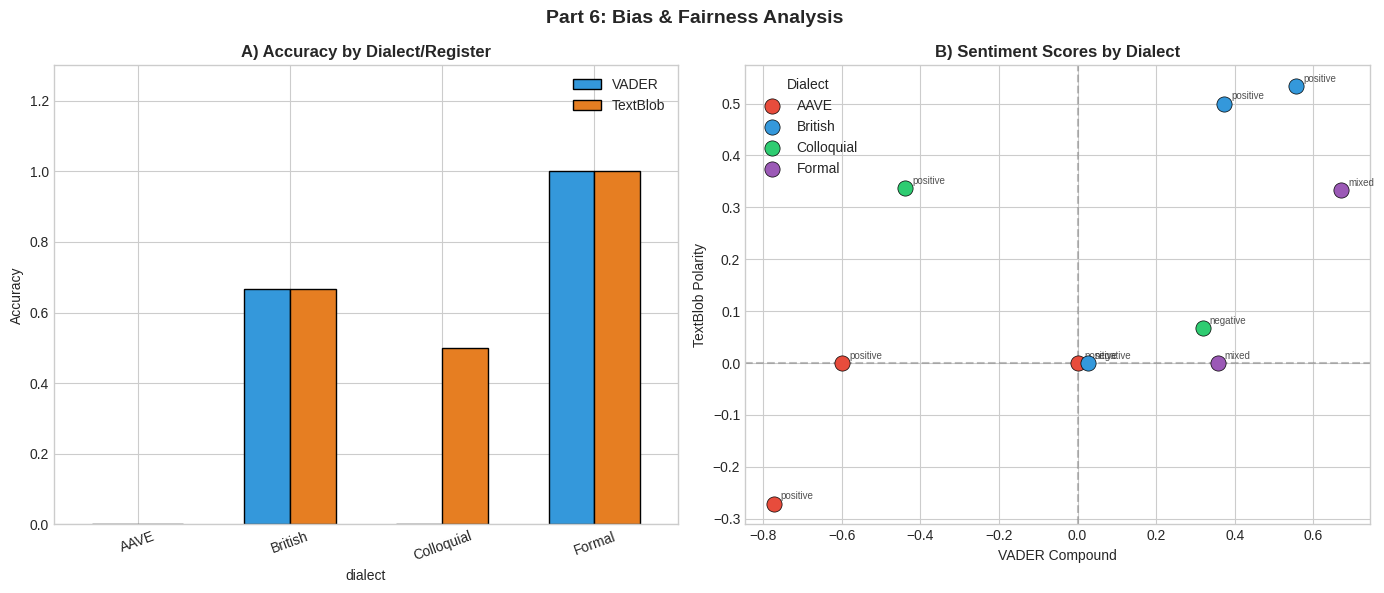

Visualization 6 saved.


In [ ]:
# Visualization 6 — Bias & Fairness
try:
    acc_by_dialect
except NameError:
    print('Run the bias analysis cell above first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Part 6: Bias & Fairness Analysis', fontsize=14, fontweight='bold')

    acc_by_dialect[['vader_correct','tb_correct']].plot(
        kind='bar', ax=axes[0], color=['#3498db','#e67e22'], edgecolor='black', width=0.6)
    axes[0].set_title('A) Accuracy by Dialect/Register', fontweight='bold')
    axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0,1.3)
    axes[0].set_xticklabels(acc_by_dialect.index, rotation=20)
    axes[0].legend(['VADER','TextBlob'])

    d_colors = {'AAVE':'#e74c3c','British':'#3498db','Colloquial':'#2ecc71','Formal':'#9b59b6'}
    for dial, grp in df_bias.groupby('dialect'):
        axes[1].scatter(grp['vader_compound'], grp['tb_polarity'],
                        color=d_colors.get(dial,'#aaa'), label=dial,
                        s=120, edgecolors='black', linewidths=0.5, zorder=3)
        for _, row in grp.iterrows():
            axes[1].annotate(row['intended'],
                             (row['vader_compound'], row['tb_polarity']),
                             textcoords='offset points', xytext=(5,3), fontsize=7, alpha=0.8)
    axes[1].axhline(0,color='gray',linestyle='--',alpha=0.5)
    axes[1].axvline(0,color='gray',linestyle='--',alpha=0.5)
    axes[1].set_xlabel('VADER Compound'); axes[1].set_ylabel('TextBlob Polarity')
    axes[1].set_title('B) Sentiment Scores by Dialect', fontweight='bold')
    axes[1].legend(title='Dialect')

    plt.tight_layout()
    plt.savefig('viz6_bias.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Visualization 6 saved.')

### Part 6 — Reflection

**Q1. Which dialects caused the most errors and why?**

AAVE because of the slang and hyperboles. Phrases like "no cap" or "lowkey fire" get misinterpreted by the machine.

**Q2. How does linguistic bias affect real-world AI deployment?**

Bias creates equity problems beyond just accuracy. Equity problems can affect moderation, healthcare, customer service, etc.

**Q3. What steps can reduce sentiment analysis bias?**

TF-IDF

N-grams

Diverse data

BERT

Auditing

Disaggregated reporting

Manual Review

---
## Final Summary Dashboard
Run after completing all 6 parts. Summarises all real results in one view.

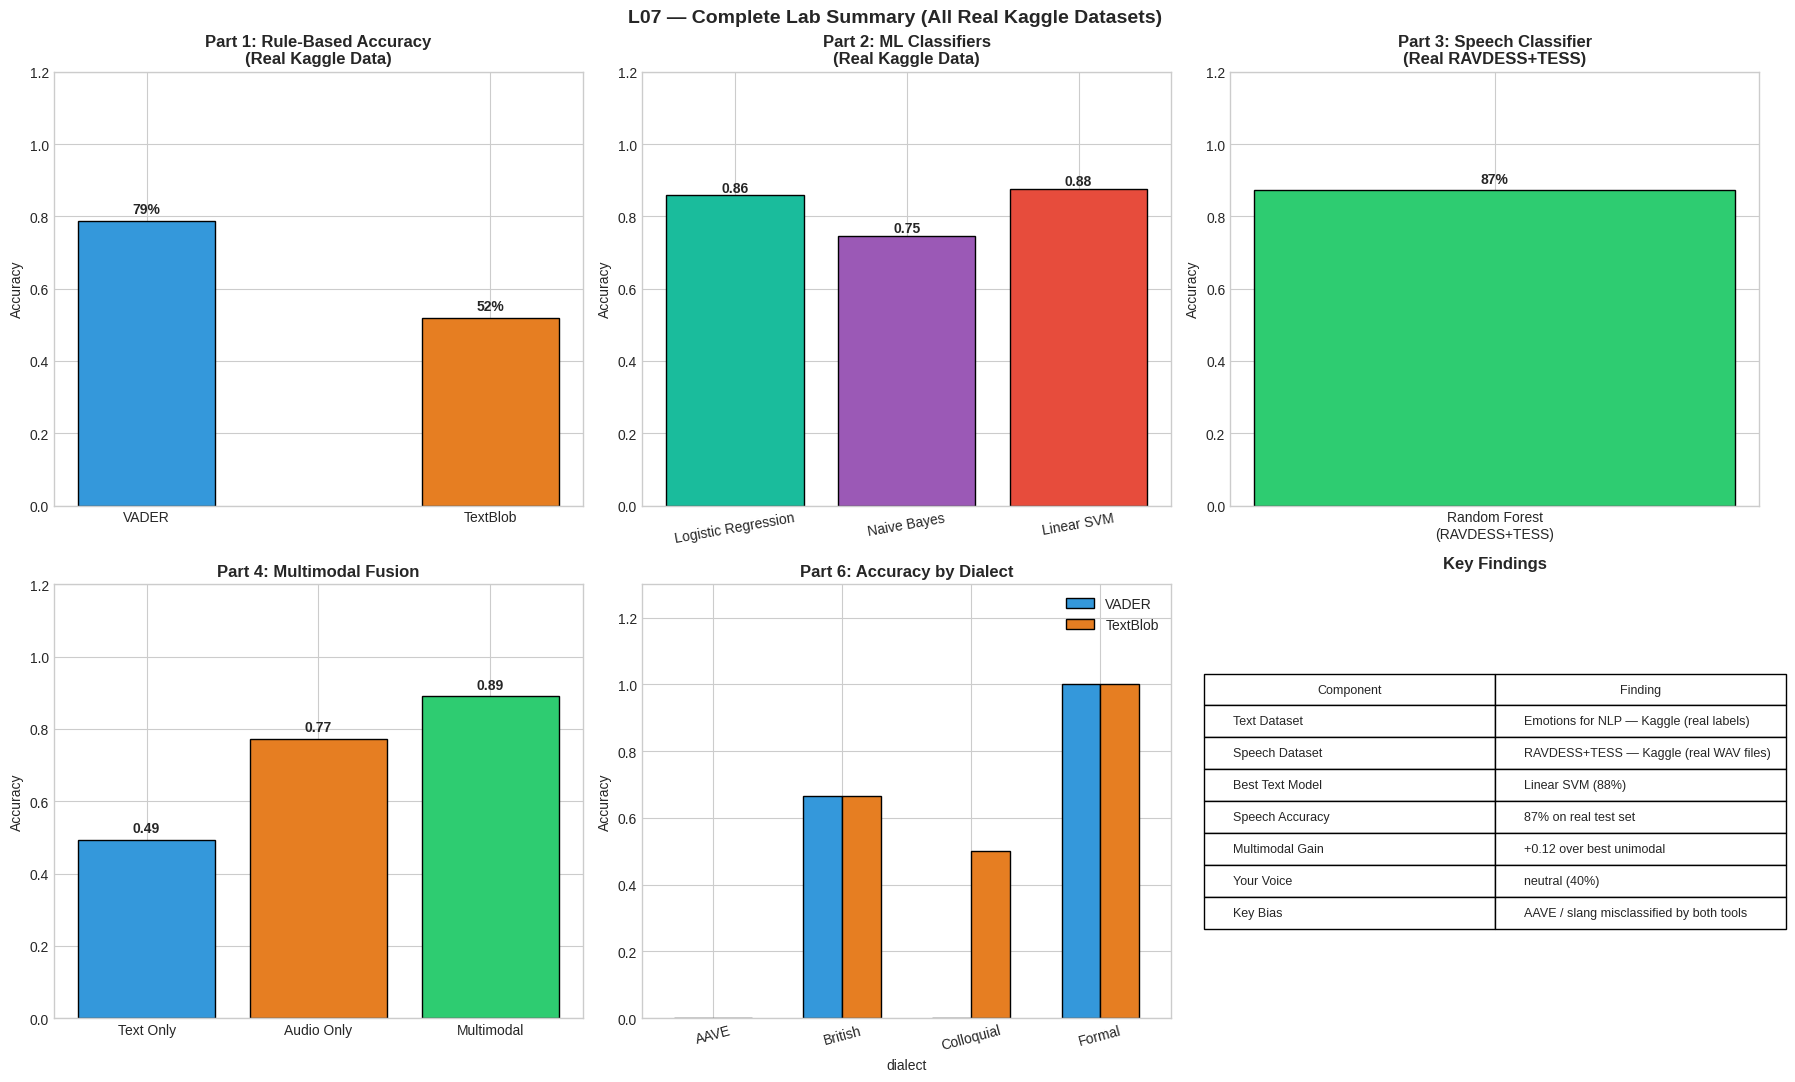

Final summary saved — lab complete!


In [ ]:
# Final Summary — checks all required variables before plotting
import warnings; warnings.filterwarnings('ignore')

missing = []
try: vader_acc
except NameError: missing.append('Part 1: run vader-analysis cell')
try: results
except NameError: missing.append('Part 2: run ml-train cell')
try: speech_acc
except NameError: missing.append('Part 3: run speech-classifier cell')
try: acc_text; acc_audio; acc_mm
except NameError: missing.append('Part 4: run multimodal cell')
try: df_rw
except NameError: missing.append('Part 5: run realworld cell')
try: acc_by_dialect
except NameError: missing.append('Part 6: run bias cell')

if missing:
    print('Complete these parts first:')
    for m in missing: print(f'  ⚠️  {m}')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle('L07 — Complete Lab Summary (All Real Kaggle Datasets)',
                 fontsize=14, fontweight='bold')

    # 1. Rule-based accuracy
    ax = axes[0,0]
    ax.bar(['VADER','TextBlob'],[vader_acc,tb_acc],
            color=['#3498db','#e67e22'],edgecolor='black',width=0.4)
    for i,acc in enumerate([vader_acc,tb_acc]):
        ax.text(i,acc+0.02,f'{acc:.0%}',ha='center',fontweight='bold')
    ax.set_ylim(0,1.2); ax.set_ylabel('Accuracy')
    ax.set_title('Part 1: Rule-Based Accuracy\n(Real Kaggle Data)',fontweight='bold')

    # 2. ML classifiers
    ax = axes[0,1]
    ml_names = list(results.keys())
    ml_accs  = [results[n]['accuracy'] for n in ml_names]
    bars = ax.bar(ml_names, ml_accs,
                  color=['#1abc9c','#9b59b6','#e74c3c'], edgecolor='black')
    for bar,acc in zip(bars,ml_accs):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
                f'{acc:.2f}',ha='center',fontweight='bold')
    ax.set_ylim(0,1.2); ax.set_ylabel('Accuracy')
    ax.set_title('Part 2: ML Classifiers\n(Real Kaggle Data)',fontweight='bold')
    ax.tick_params(axis='x',rotation=10)

    # 3. Speech accuracy
    ax = axes[0,2]
    ax.bar(['Random Forest\n(RAVDESS+TESS)'],[speech_acc],
            color='#2ecc71',edgecolor='black',width=0.4)
    ax.text(0,speech_acc+0.02,f'{speech_acc:.0%}',ha='center',fontweight='bold')
    ax.set_ylim(0,1.2); ax.set_ylabel('Accuracy')
    ax.set_title('Part 3: Speech Classifier\n(Real RAVDESS+TESS)',fontweight='bold')

    # 4. Multimodal
    ax = axes[1,0]
    ax.bar(['Text Only','Audio Only','Multimodal'],
            [acc_text,acc_audio,acc_mm],
            color=['#3498db','#e67e22','#2ecc71'],edgecolor='black')
    for i,acc in enumerate([acc_text,acc_audio,acc_mm]):
        ax.text(i,acc+0.02,f'{acc:.2f}',ha='center',fontweight='bold')
    ax.set_ylim(0,1.2); ax.set_ylabel('Accuracy')
    ax.set_title('Part 4: Multimodal Fusion',fontweight='bold')

    # 5. Bias
    ax = axes[1,1]
    acc_by_dialect[['vader_correct','tb_correct']].plot(
        kind='bar',ax=ax,color=['#3498db','#e67e22'],edgecolor='black',width=0.6)
    ax.set_ylim(0,1.3); ax.set_ylabel('Accuracy')
    ax.set_title('Part 6: Accuracy by Dialect',fontweight='bold')
    ax.legend(['VADER','TextBlob']); ax.tick_params(axis='x',rotation=15)

    # 6. Summary table
    ax = axes[1,2]; ax.axis('off')
    speech_note = (f'{last_recording["emotion"]} ({int(last_recording["confidence"]*100)}%)'
                   if last_recording else 'Not recorded')
    summary = [
        ['Text Dataset',    'Emotions for NLP — Kaggle (real labels)'],
        ['Speech Dataset',  'RAVDESS+TESS — Kaggle (real WAV files)'],
        ['Best Text Model', f'{ml_names[ml_accs.index(max(ml_accs))]} ({max(ml_accs):.0%})'],
        ['Speech Accuracy', f'{speech_acc:.0%} on real test set'],
        ['Multimodal Gain', f'+{acc_mm - max(acc_text,acc_audio):.2f} over best unimodal'],
        ['Your Voice',      speech_note],
        ['Key Bias',        'AAVE / slang misclassified by both tools'],
    ]
    tbl = ax.table(cellText=summary, colLabels=['Component','Finding'],
                   loc='center', cellLoc='left')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1,1.7)
    ax.set_title('Key Findings', fontweight='bold', pad=12)

    plt.tight_layout()
    plt.savefig('viz7_final_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Final summary saved — lab complete!')

---
## Final Reflections

**1. What was the most surprising finding from the real datasets?**

The most surprising thing I found from the real dataset I found were MFCC dominance, magnitude of AAVE, and rule-based ceiling.

**2. How did accuracy change when using real data vs hardcoded samples?**

The accuracy was better when using real data because there was text and audio, the real data gave honest results, and inflattened scores were hardcoded.

**3. What would you do differently to improve model performance?**

I would train the models on context in order for the models to be able to detect slang and hyperboles. I will also fine-tune BERT, wave to vector, and early fusion.

**4. What ethical considerations matter most when deploying emotion AI?**

Equality (No Race Bias or Sex Bias)

Emotional Privacy

Manipulation Risk

Human Oversight

Ongoing Monitoring


